<a href="https://colab.research.google.com/github/Gerardocmdz/Verano_IA_2026/blob/main/AF5_Artificial%20Neural%20Network_feedforward/AF5_Artificial_Neural_Network_feedforward_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AF5_Artificial Neural Network_feedforward.


Members of the team:

**Gerardo Alberto Córdova Méndez**

ID: **2099413**

**Alejandro Francisco Flores Teillery**

ID: **2101406**

**Octavio Rodriguez Cazarez**

ID: **2100243**

 **Cristian Alexis De La Cruz Cabrera**

ID:  **2065212**

Class Schedule:V4

**Primero cargaremos las librerias que utilizaremos en esta actividad :**

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

**Importaremos las imagenes de la base de datos de MNIST desde keras las cuales son numeros del 0 al 9**

In [ ]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Definimos los nombres de las clases (los numeros del 0 al 9)**


In [ ]:
class_names = [str(i) for i in range(10)]

**Daremos una previsualización de las imágenes para comprobar que se hayan cargado correctamente**

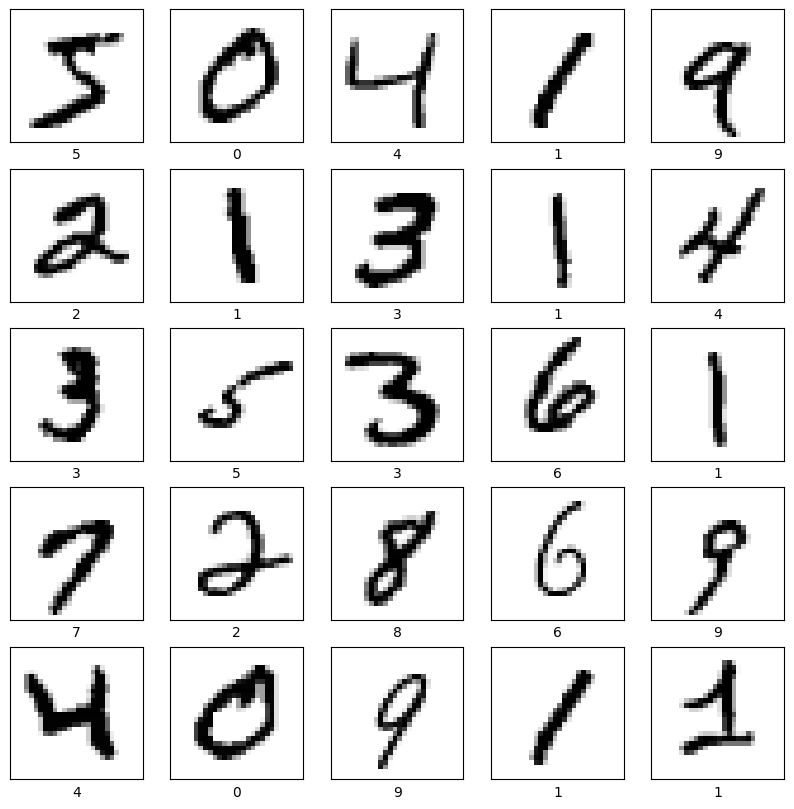

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.xlabel(class_names[train_labels[i]])
    plt.imshow(train_images[i], cmap=plt.cm.binary)


**Se crea una escala de grises de una imagen para poder normalizarlos en el siguiente paso**

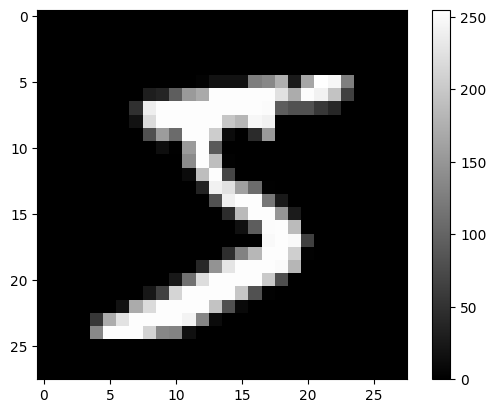

In [ ]:
plt.figure()
plt.imshow(train_images[0], cmap="gray", vmin=0, vmax=255)
plt.colorbar()
plt.grid(False)



**Normalizamos los datos para que se encuentren entre 0 y 1**

In [ ]:
train_images = train_images / 255.0

test_images = test_images / 255.0

**Primero con la función "Flatten" creamos un vector de una sola dimensión**

**Posteriormente establecemos las especificaciones de nuestra red neuronal:**


*   La primera capa profunda de de 256 neuronas
*   La segunda capa profunda con 128

**Y nuestra capa de salida de 10 neuronas (debido a que solo podemos dar etiquetas de 0 al 9 )**


In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

**Iniciamos el entrenamiento de nuestra red, y establecemos nuestras épocas de entrenamiento:**


In [ ]:
model.fit(train_images, train_labels, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9388 - loss: 0.2023
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9747 - loss: 0.0826
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9813 - loss: 0.0609
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9855 - loss: 0.0439
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9889 - loss: 0.0343
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9909 - loss: 0.0273
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9919 - loss: 0.0252
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9933 - loss: 0.0198
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9939 - loss: 0.0177
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9946 - loss: 0.0169


**Imprimimos nuestra precisión obtenida, en este caso fue del 98%**

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.9815 - loss: 0.0864

Test accuracy: 0.9815000295639038


**Probamos nuestra red con imágenes que están fuera del entrenamiento para comprobar su precisión**

In [ ]:
model.evaluate(test_images,  test_labels, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.9815 - loss: 0.0864


[0.08642647415399551, 0.9815000295639038]

**En este paso realizamos 5 predicciones diferentes, con el conjunto de datos de prueba**

In [ ]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**Para comprobar que nuestro modelo está en lo correcto, nuestra predicción (el primer dígito que se imprime) debe coincidir con la etiqueta real de la imagen (el último dígito que se imprime)**

**Predicción 1**

In [ ]:
print (class_names[np.argmax(predictions[0])])
print(predictions[0])
print(class_names[test_labels[0]])

7
[2.5825779e-14 8.2915133e-11 8.3672574e-12 1.6096099e-08 5.7288663e-15
 1.5845928e-14 3.0509763e-18 9.9999994e-01 6.2484353e-14 1.4513517e-08]
7


**Predicción 2**

In [ ]:
print (class_names[np.argmax(predictions[5])])
print(predictions[5])
print(class_names[test_labels[5]])

1
[6.2101068e-14 9.9999434e-01 7.2342149e-13 1.2238139e-13 4.4911977e-07
 1.0911354e-12 2.4790496e-11 2.6831865e-06 2.3852856e-06 2.5641713e-11]
1


**Predicción 3**

In [ ]:
print (class_names[np.argmax(predictions[-1])])
print(predictions[-1])
print(class_names[test_labels[-1]])

6
[2.3853879e-15 9.3298937e-21 5.8069548e-22 2.5614657e-20 5.2605056e-18
 7.1068792e-15 9.9999994e-01 1.2861735e-21 2.7068253e-16 7.0652913e-19]
6


**Predicción 4**

In [ ]:
print (class_names[np.argmax(predictions[200])])
print(predictions[200])
print(class_names[test_labels[200]])

3
[1.0233480e-15 1.8227513e-10 1.4006500e-10 9.9998933e-01 1.1983295e-14
 4.1026542e-06 1.2184084e-14 1.8768518e-11 6.5015984e-06 7.8092158e-11]
3


**Predicción 5**

In [ ]:
print (class_names[np.argmax(predictions[68])])
print(predictions[68])
print(class_names[test_labels[68]])

3
[9.4299910e-25 3.1060774e-17 3.2910327e-20 9.9999994e-01 4.2629397e-22
 1.8455022e-14 2.3816442e-28 7.5362247e-16 1.3997434e-14 3.1153177e-12]
3


**Le daremos una mejor visualización a los resultados con una imagen y un gráfico que indicara el nivel de certeza que ha tenido**

In [ ]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(len(class_names)))
  plt.yticks([])
  thisplot = plt.bar(range(len(class_names)), predictions_array, color="#877777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

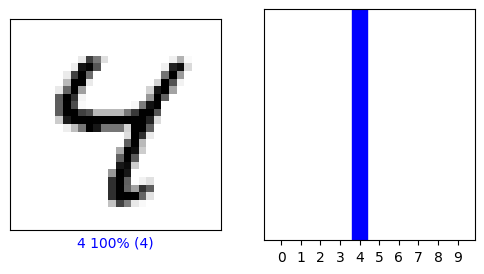

In [ ]:
i = 6
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()